## Newton's Method for Normal Distribution Transforms.

This notebook walks through the optimization method employed by the normal distribution transform.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import plotting as plot

from copy import copy
from typing import Callable

#### Newton's method in 1-D

To find the minimum of the function, $f(x)$, we would simply compute $f'(x) = 0$. If $x$ cannot be isolated in $f'(x)$, however, solving for the minima requires an iterative method. An example is a curve with the equation:

\begin{align*}
f(x) = x^2 + e^{-x}
\end{align*}

whose derivative is

\begin{align*}
f'(x) = 2x - e^{-x}
\end{align*}

These functions are defined and plotted below.

C:\Users\user\AppData\Local\Temp\ipykernel_161324\2121208960.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_univariate_functions( funcs = [f, f_d], labels = ['f(x)', "f'(x)"], x_range = (-1, 1) ).show()


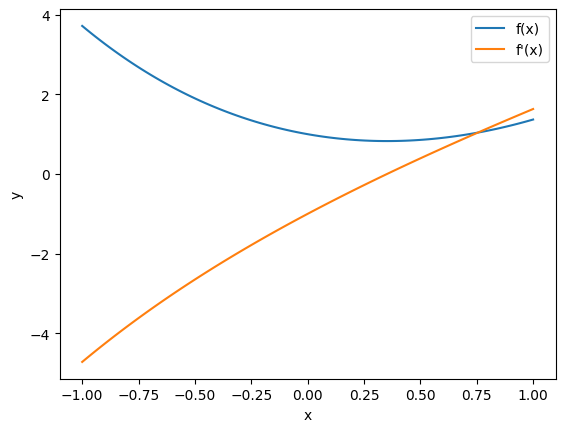

In [10]:
def f( x: float ) -> float:
    return x ** 2 + np.exp( -x )

def f_d( x: float ) -> float:
    return 2 * x - np.exp( -x )

plot.plot_univariate_functions( funcs = [f, f_d], labels = ['f(x)', "f'(x)"], x_range = (-1, 1) ).show()

To first show gradient escent in action, we'll start with a derivate for which the local minima is easily found, $f(x) = ( x - 2 )^2$. The minima can be found by setting the derivative equal to $0$, $f'(x) = 2 ( x - 2 ) = 2x - 4 = 0 \rightarrow x = 2$. This can be confirmed visually in the plot below.

C:\Users\user\AppData\Local\Temp\ipykernel_161324\3186809734.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_univariate_functions( funcs = [f], labels = ['f(x)'], x_range = (-10, 10) ).show()


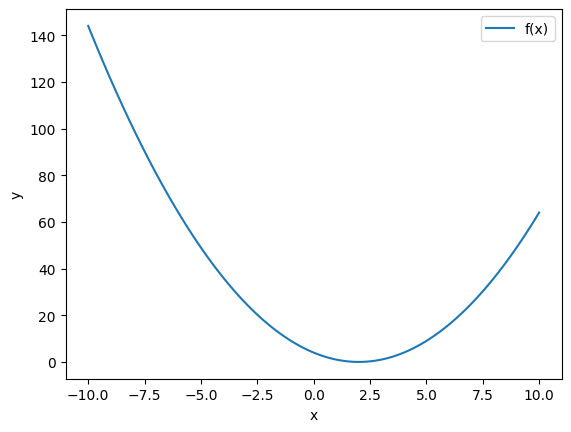

In [11]:
def f( x: float ) -> float:
    return ( x - 2 ) ** 2

plot.plot_univariate_functions( funcs = [f], labels = ['f(x)'], x_range = (-10, 10) ).show()

If it were not so easy to determine the value of $x$ where $f'(x) = 0$, we could use Newton's method to iteratively find the minima. Let's say we had an initial guess that $f'(-2) = 0$. Our initial guess, $x_n = -2$, could then be improved by computing the $x_{n + 1} = x_n - \alpha d_k$, where $\alpha$ is the learning rate (or step size) in the direction of $d_k$, which is the direction of descent toward the minima. Since the derivative $f'(x)$ represents the tangent line of $f(x)$ at any given $x$, we can simply set $d_k = f'(x)$. Thus, the iterative equation is then $x_{n + 1} = x_n - \alpha f'(x_n)$. Below are examples solving for th iterative method with a termination criteria of $\epsilon < 0.001$, meaning that the algorithm stops when $| \Delta f(x) | = | f(x_{n + 1}) - f(x_n) | < 0.001$.

C:\Users\user\AppData\Local\Temp\ipykernel_161324\1448738240.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10) ).show()


Minima found at x = 1.98548811776


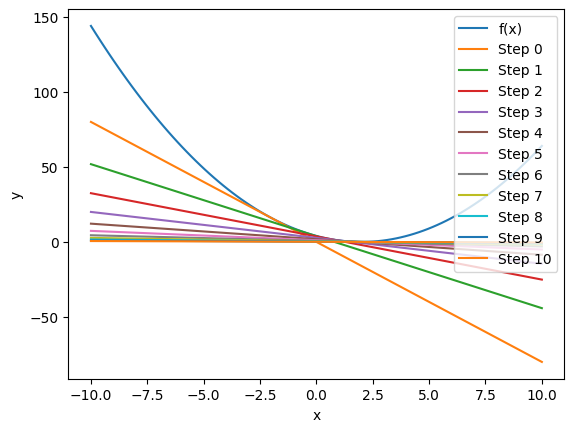

In [12]:
def gradient_descent_1d_func_gen( f: Callable[[float], float], f_d: Callable[[float], float], x_0: float, learning_rate: float = 0.2, epsilon: float = 0.001 ) -> list[Callable[[float], float]]:
    
    delta_f: float = epsilon * 10
    x: float = x_0

    f_n: list[Callable[[float], float]] = [f]
    
    while( delta_f > epsilon ):
        m = f_d( x )
        b = f( x ) - m * x

        f_n.append( lambda x_n, m = m, b = b: m * x_n + b )

        f_xn_1 = f( x )
        x = x - learning_rate * f_d( x )
        f_xn = f( x)

        delta_f = abs( f_xn - f_xn_1 )

    print( f"Minima found at x = {x}" )

    return f_n

def f( x: float ) -> float:
    return ( x - 2 ) ** 2

def f_d( x: float ) -> float:
    return  2 * ( x - 2 )

plottable_funcs = gradient_descent_1d_func_gen( f = f, f_d = f_d, x_0 = -2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10) ).show()

As shown, the algorithm above computed $x = 1.985$, near to the analytical value found at $x = 2$. A smaller $\epsilon$ (and potentially smaller $\alpha$ to avoid overshooting), would yield an even more accurate result. Using the example above of a function for which finding the analytical solution is is not practical, $f(x) = x^2 + e^{-x}$, gradient descent works just as well.

Minima found at x = 0.3636200610598141


C:\Users\user\AppData\Local\Temp\ipykernel_161324\1225739881.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-5, 5) ).show()


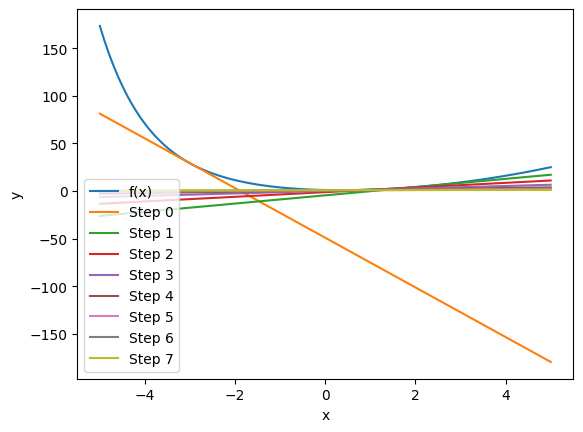

In [13]:
def f( x: float ) -> float:
    return x ** 2 + np.exp( -x )

def f_d( x: float ) -> float:
    return  2 * x - np.exp( -x )

plottable_funcs = gradient_descent_1d_func_gen( f = f, f_d = f_d, x_0 = -3, learning_rate = 0.2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-5, 5) ).show()

Unfornately, the last example shows the sensitivity of the algorithm to $\alpha$. The gradient descent can be seen overshooting the solution in step 1, then backtracking to find the minima at $x = 0.364$. To mitigate this, Newton's Method exploits the curvature information continaed in $f''(x)$ to set the value of $\alpha$. The equation for Newton's Method is

\begin{align*}
x_{n + 1} = x_n - f''(x)^{-1} f'(x)
\end{align*}

In a simple example, such as $f(x) = x^2$, $f''(x) = 2$, meaning that the ideal learning rate for a simple parabola is $2^{-1} = 0.5$. A plot with this higher learning rate is shown below.

Minima found at x = 2.0


C:\Users\user\AppData\Local\Temp\ipykernel_161324\975835239.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10) ).show()


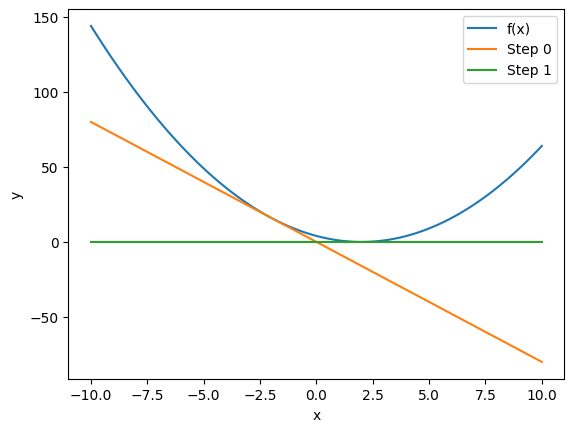

In [14]:
def newtons_method_1d_func_gen( f: Callable[[float], float], f_d: Callable[[float], float], f_dd: Callable[[float], float], x_0: float, epsilon: float = 0.001 ) -> list[Callable[[float], float]]:
    
    delta_f: float = epsilon * 10
    x: float = x_0

    f_n: list[Callable[[float], float]] = [f]
    
    while( delta_f > epsilon ):
        m = f_d( x )
        b = f( x ) - m * x

        f_n.append( lambda x_n, m = m, b = b: m * x_n + b )

        f_xn_1 = f( x )
        x = x - f_d( x ) / f_dd( x )
        f_xn = f( x)

        delta_f = abs( f_xn - f_xn_1 )

    print( f"Minima found at x = {x}" )

    return f_n

def f( x: float ) -> float:
    return ( x - 2 ) ** 2

def f_d( x: float ) -> float:
    return  2 * ( x - 2 )

def f_dd( x: float ) -> float:
    return 2

plottable_funcs = newtons_method_1d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = -2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10) ).show()

Compared to our guess of $\alpha = 0.2$ using gradient descent, Newton's Method solved for the minima perfectly in 1 iteration. Shown below on $f(x) = x^2 + e^{-x}$, Newton's Method solved for the minima in 3 steps (rather than 7, above), and converged without overshooting.

Minima found at x = 0.35172483870686516


C:\Users\user\AppData\Local\Temp\ipykernel_161324\2979069093.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-5, 5) ).show()


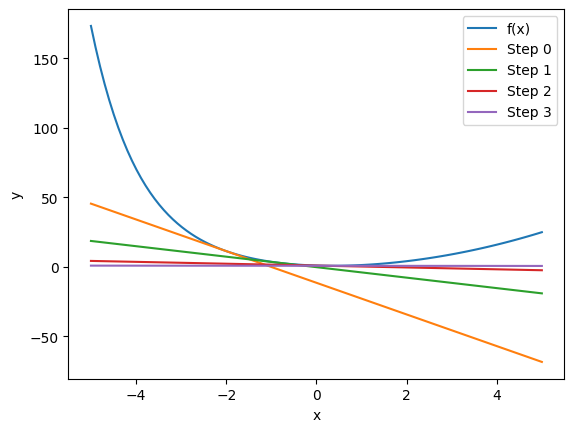

In [15]:
def f( x: float ) -> float:
    return x ** 2 + np.exp( -x )

def f_d( x: float ) -> float:
    return  2 * x - np.exp( -x )

def f_dd( x: float ) -> float:
    return 2 + np.exp( -x )

plottable_funcs = newtons_method_1d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = -2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-5, 5) ).show()

Extending this to a multivariate problem, the code below shows Newton's method for a classic "bowl" problem in 2 dimensions, centered at $( 2, -5 )$. The equation becomes $f(x) = ( x_1 - 2 )^2 + ( x_2 + 5 )^2 = x_1^2 - 4 x_1 + 4 + x_2^2 + 10 x_2 + 25 = x_1^2 + x_2^2 - 4 x_1 + 10 x_2 + 4 + 25$. In matrix form, the equation is:

\begin{align*}
f(x) = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} -4 & 10 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 4 & 25 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix}
\end{align*}

Computing the Jacobian (first derivative), which should have the dimensions of $outputs \times inputs$, yields:

\begin{align*}
J = \begin{bmatrix} \frac{\delta f}{\delta x_1} & \frac{\delta f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 2 x_1 - 4 & 2 x_2 + 10 \end{bmatrix}
\end{align*}

Finally, computing the Hessian yields:

\begin{align*}
H = \begin{bmatrix} \frac{\delta^2 f}{\delta x_1} & \frac{\delta^2 f}{\delta x_1 x_2} \\ \frac{\delta^2 f}{\delta x_2 x_1} & \frac{\delta^2 f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix}
\end{align*}

C:\Users\user\AppData\Local\Temp\ipykernel_161324\4164668088.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.plot_multivariate_functions( funcs = [ f ], labels = [ 'f(x)' ], x_range = (-10, 10) ).show()


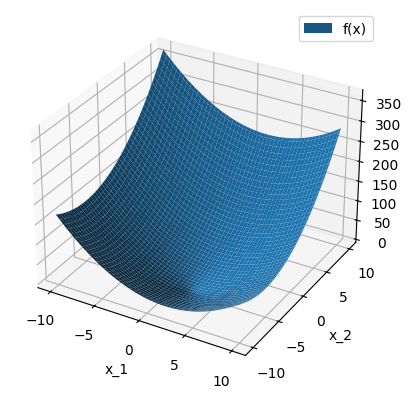

In [ ]:
def newtons_method_2d_func_gen( f: Callable[[float], float], f_d: Callable[[float], float], f_dd: Callable[[float], float], x_0: float, epsilon: float = 0.001 ) -> list[Callable[[float], float]]:
    
    delta_f: float = epsilon * 10
    x: float = x_0

    f_n: list[Callable[[float], float]] = [f]
    
    while( delta_f > epsilon ):
        m = f_d( x )
        b = f( x ) - m * x

        f_n.append( lambda x_n, m = m, b = b: m * x_n + b )

        f_xn_1 = f( x )
        x = x - f_d( x ) / f_dd( x )
        f_xn = f( x)

        delta_f = abs( f_xn - f_xn_1 )

    print( f"Minima found at x = {x}" )

    return f_n

def f( x1: float, x2: float ) -> float:
    return ( x1 - 2 ) ** 2 + ( x2 + 5 ) ** 2

def f_d( x1: float, x2: float ) -> float:
    return  2 * ( x1 - 2 ) + 2 * ( x2 + 5 )

def f_dd( x1: float, x2: float ) -> float:
    return 4

# plottable_funcs = newtons_method_1d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = -2 )
# labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
# labels[0] = "f(x)"

plot.plot_multivariate_functions( funcs = [ f ], labels = [ 'f(x)' ], x_range = (-10, 10) ).show()